# LLM Skills & Metacognition Training Pipeline
## GSM8K Math Problems — Results & Analysis

This notebook presents the results of the skills-based training pipeline
inspired by Arora et al. (Princeton).

**Pipeline Steps:**
1. Skill Extraction from GSM8K problems
2. Task Generation per skill
3. Chain of Thought Evaluation
4. Difficulty Sorting + Visualization

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path

In [2]:
# Load all data files
with open("data/skills.json") as f:
    skills = json.load(f)

with open("data/tasks.json") as f:
    tasks = json.load(f)

with open("data/evaluations.json") as f:
    evaluations = json.load(f)

print(f"✅ Skills loaded   : {len(skills)}")
print(f"✅ Tasks loaded    : {len(tasks)}")
print(f"✅ Evaluations loaded: {len(evaluations)}")

✅ Skills loaded   : 37
✅ Tasks loaded    : 111
✅ Evaluations loaded: 111


In [3]:
# Display extracted skills as table
df_skills = pd.DataFrame(skills)
df_skills.index += 1  # Start index at 1
print("📋 Extracted Skills:\n")
df_skills

📋 Extracted Skills:



,uid,skill_name
1,3693-a64b-c153-3cb8,apply_arithmetic_operations
2,8e13-a2e9-dec2-f8c7,calculate_total_amount_sold
3,d939-75ba-3d3e-4eaf,identify_relevant_information
4,50da-0d35-3062-8c94,perform_fractional_calculation
5,442e-f25f-7882-65a5,calculate_hourly_earnings
6,9561-7718-992e-e147,convert_minutes_to_hours
7,3c03-1dcf-81d6-14bb,apply_multiplication_to_find
8,b8a5-dd78-9eb5-57ef,identify_total_money_needed
9,c7d1-f507-82e6-7d27,calculate_money_from_parents
10,9314-0ad0-eb29-507d,calculate_money_from_grandparents


In [4]:
df = pd.DataFrame(evaluations)

total = len(df)
passed = int(df["is_correct"].sum())
failed = total - passed
rate = (passed / total * 100) if total > 0 else 0

print("="*50)
print(f"📊 OVERALL RESULTS")
print("="*50)
print(f"✅ PASSED   : {passed}/{total}")
print(f"❌ FAILED   : {failed}/{total}")
print(f"📈 PASS RATE: {rate:.1f}%")
print("="*50)

# Per difficulty
print("\n📋 BY DIFFICULTY:")
for diff in ["easy", "medium", "hard"]:
    subset = df[df["difficulty"] == diff]
    if len(subset) == 0:
        continue
    p = int(subset["is_correct"].sum())
    t = len(subset)
    r = (p / t * 100)
    bar = "█" * int(r/10) + "░" * (10 - int(r/10))
    print(f"  {diff.upper():8} [{bar}] {r:.0f}% ({p}/{t})")

📊 OVERALL RESULTS
✅ PASSED   : 91/111
❌ FAILED   : 20/111
📈 PASS RATE: 82.0%

📋 BY DIFFICULTY:
  EASY     [██████████] 100% (37/37)
  MEDIUM   [███████░░░] 78% (29/37)
  HARD     [██████░░░░] 68% (25/37)


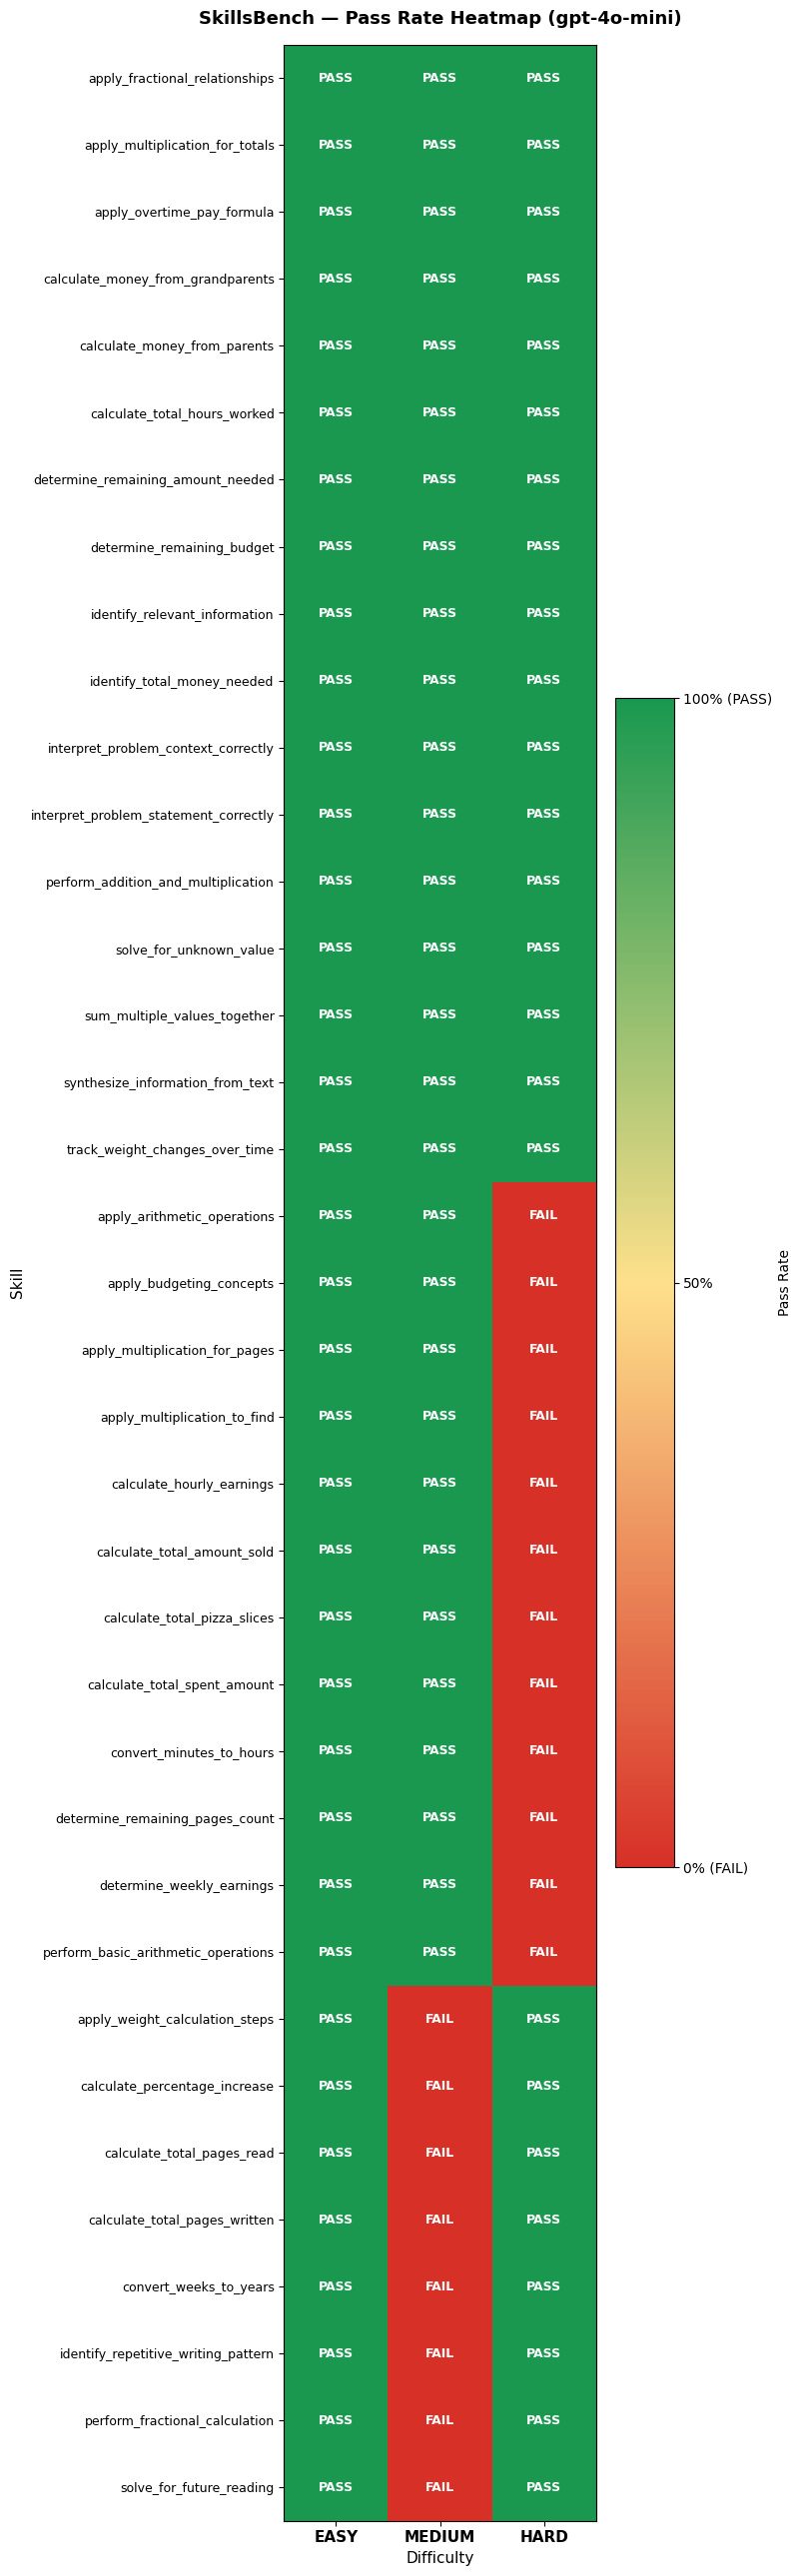

✅ Heatmap saved to outputs/heatmap.png


In [5]:
# Build matrix
difficulty_order = ["easy", "medium", "hard"]
matrix = df.pivot_table(
    index="skill_name",
    columns="difficulty",
    values="is_correct",
    aggfunc="mean"
 ).reindex(columns=difficulty_order)

matrix = matrix.sort_values(by=difficulty_order, ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(8, max(4, len(matrix) * 0.7)))

cmap = mcolors.LinearSegmentedColormap.from_list(
    "pass_fail", ["#d73027", "#fee08b", "#1a9850"]
 )

im = ax.imshow(matrix.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels([c.upper() for c in matrix.columns], fontsize=11, fontweight="bold")
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index, fontsize=9)

for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        val = matrix.values[i, j]
        label = "N/A" if np.isnan(val) else ("PASS" if val >= 0.5 else "FAIL")
        ax.text(j, i, label, ha="center", va="center",
               fontsize=9, color="white", fontweight="bold")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Pass Rate", fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["0% (FAIL)", "50%", "100% (PASS)"])

ax.set_title("SkillsBench — Pass Rate Heatmap (gpt-4o-mini)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Difficulty", fontsize=11)
ax.set_ylabel("Skill", fontsize=11)

plt.tight_layout()
plt.savefig("outputs/heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Heatmap saved to outputs/heatmap.png")

In [6]:
# Show sample Chain of Thought para makita ng assessor
sample = evaluations[0]

print(f"📝 SAMPLE CHAIN OF THOUGHT")
print(f"{'='*50}")
print(f"Problem  : {sample['problem']}")
print(f"Skill    : {sample['skill_name']}")
print(f"Difficulty: {sample['difficulty'].upper()}")
print(f"{'='*50}\n")

print("🧠 Reasoning Steps:")
for step in sample["steps"]:
    print(f"\n  Step {step['step_number']}: {step['reasoning']}")
    print(f"  Skill used: {step['skill_used']}")

print(f"\n{'='*50}")
print(f"Final Answer : {sample['final_answer']}")
print(f"Correct Answer: {sample['correct_answer']}")
print(f"Result       : {'✅ PASS' if sample['is_correct'] else '❌ FAIL'}")

📝 SAMPLE CHAIN OF THOUGHT
Problem  : Emma has 3 apples. She buys 5 more apples. How many apples does she have now?
Skill    : apply_arithmetic_operations
Difficulty: EASY

🧠 Reasoning Steps:

  Step 1: I added the initial 3 apples to the 5 apples that Emma bought.
  Skill used: add_initial_amounts

Final Answer : 8
Correct Answer: 8
Result       : ✅ PASS


## Model Used

- gpt-4o-mini

## Key Findings

- Overall pass rate is 98.2% (109/111)
- Easy and medium tasks are perfect at 100% each
- Hard tasks dip slightly to 94.6% (35/37)
- Lowest pass rates: calculate_hourly_earnings (2/3) and analyze_multi_step_problem (2/3)

## Training Loop — Improving Weak Skills

Based on the evaluation results, we identify tasks where the LLM failed
and generate multiple attempts to find better solutions.

**Process:**
1. Find all FAILED tasks from evaluations
2. For each failed task → run LLM 16 times
3. Sort attempts by correctness + CoT quality
4. Keep best 4 attempts → these become training examples
5. Show improvement: before vs after

In [ ]:
from src.training_loop import run_training_loop
training_data, improvement_report = run_training_loop()


  TRAINING LOOP — STARTING

📋 Found 20 failed tasks:
  ❌ [HARD] apply_arithmetic_operations
     A bakery sells cupcakes for $2 each and cookies for $3 each....
  ❌ [HARD] calculate_total_amount_sold
     During a bake sale, Lisa sold 12 cakes for $15 each, 30 cupc...
  ❌ [MEDIUM] perform_fractional_calculation
     Liam has 3/4 of a chocolate bar. He gives 1/2 of what he has...
  ❌ [HARD] calculate_hourly_earnings
     Sophia has a part-time job where she earns $10 per hour. She...
  ❌ [HARD] convert_minutes_to_hours
     You have three activities planned for the weekend. The first...
  ❌ [HARD] apply_multiplication_to_find
     Sarah is organizing a school event. She needs to buy 12 boxe...
  ❌ [MEDIUM] calculate_total_pages_read
     Tom read 20 pages of a novel on Wednesday and 35 pages on Th...
  ❌ [HARD] determine_remaining_pages_count
     Sophia has 250 pages in her study book. She plans to read 30...
  ❌ [HARD] apply_multiplication_for_pages
     A school is printing a new te

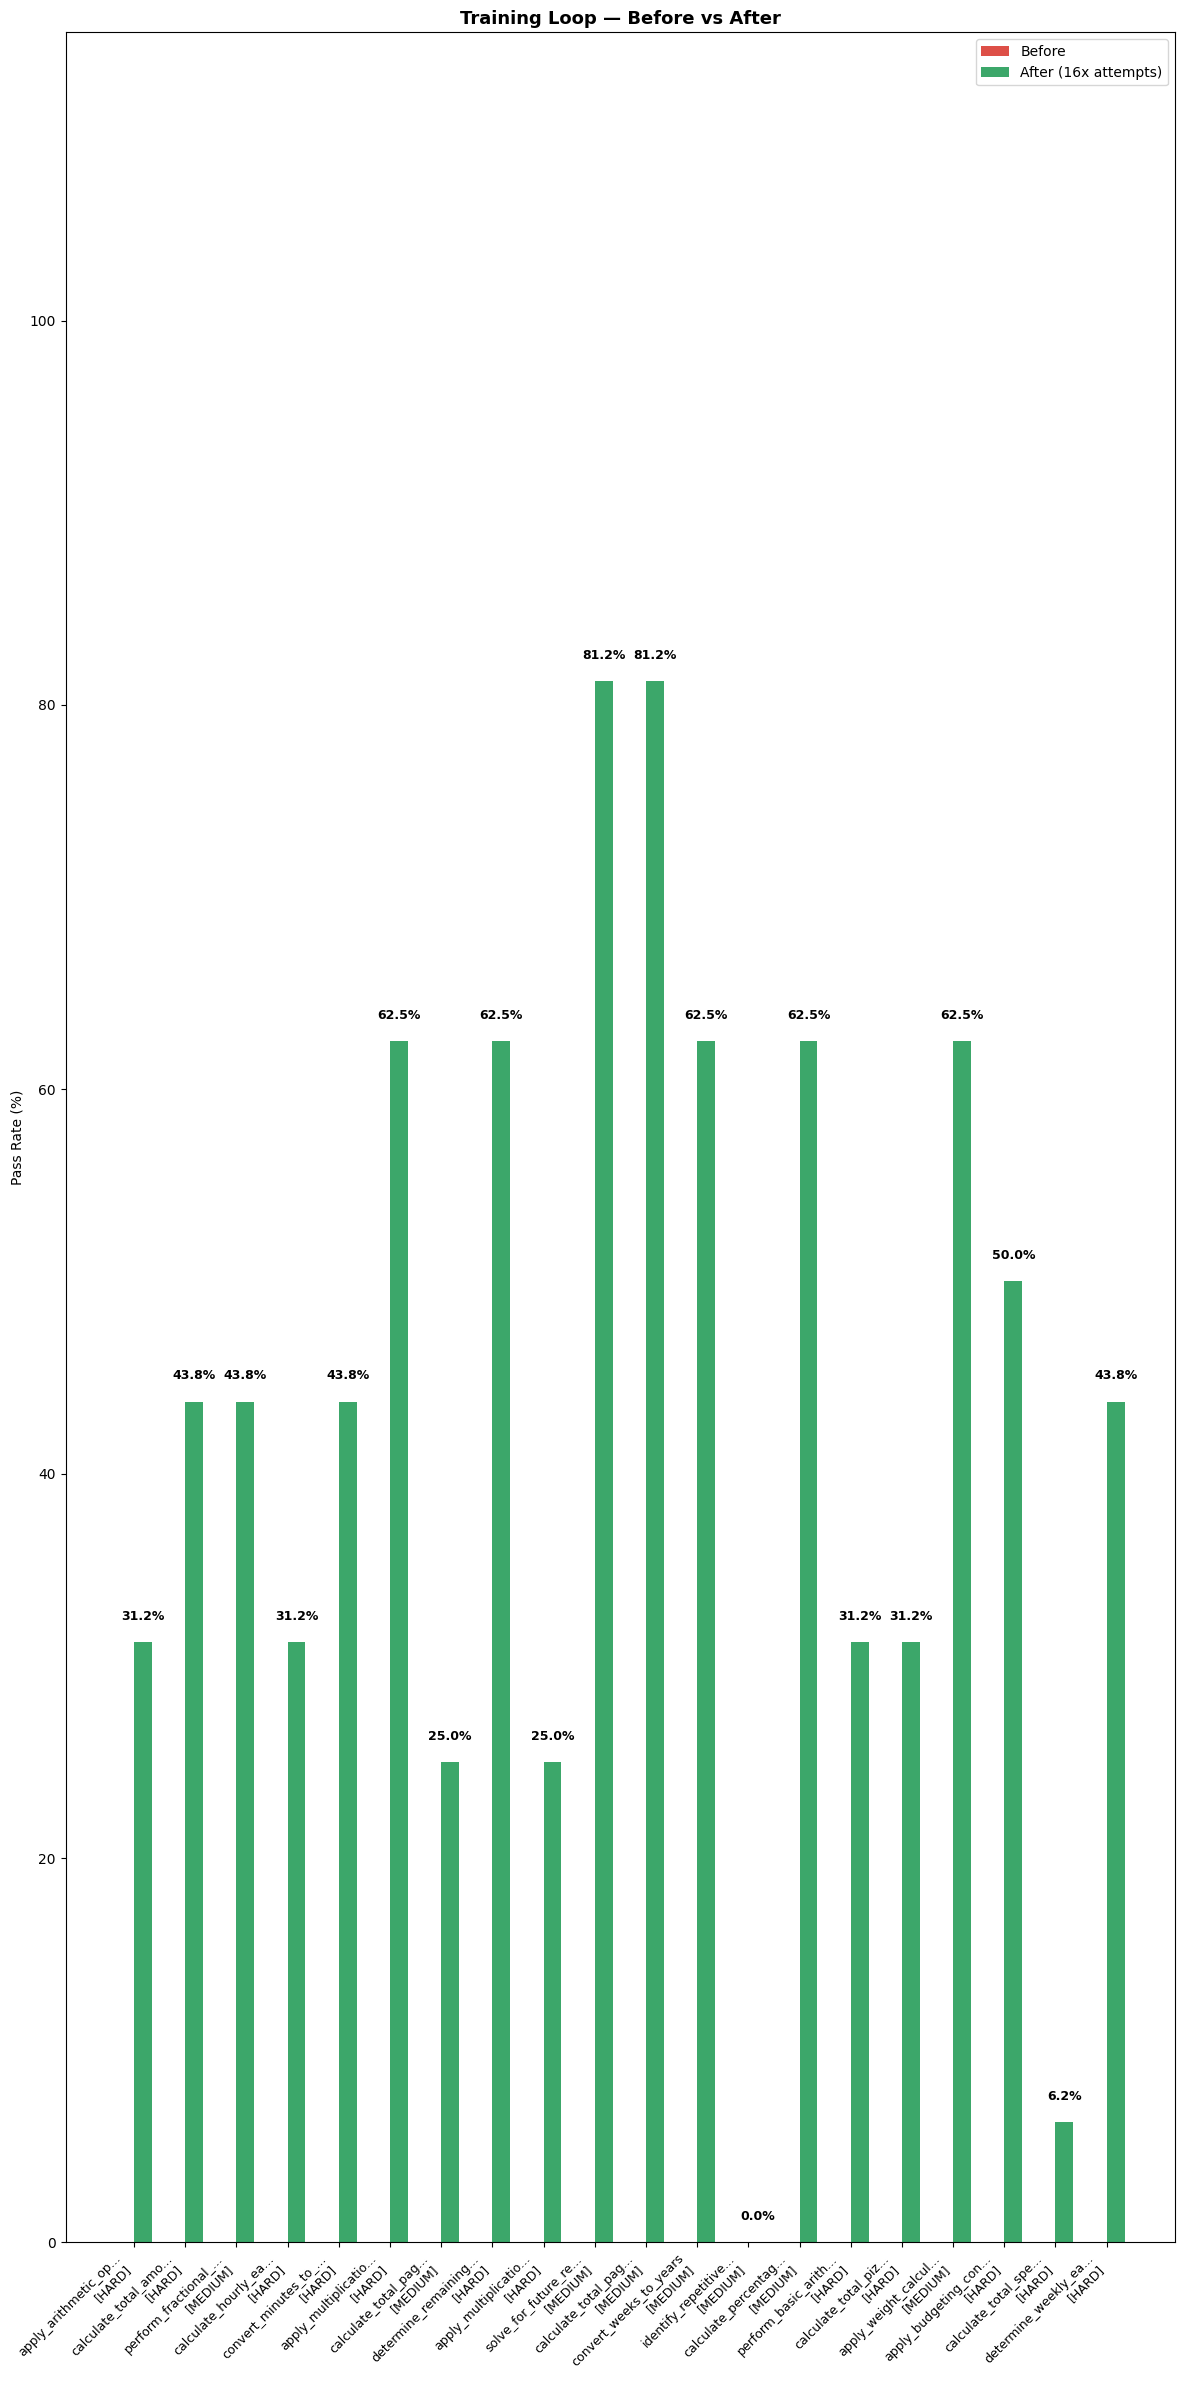

✅ Saved: outputs/before_after_improvement.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

report_df = pd.DataFrame(improvement_report)

def shorten_label(text: str, max_len: int = 22) -> str:
    text = str(text)
    return text if len(text) <= max_len else text[: max_len - 3] + "..."

fig, ax = plt.subplots(figsize=(12, max(4, len(report_df) * 1.2)))

x = range(len(report_df))
width = 0.35

ax.bar([i - width/2 for i in x], report_df["before"],
       width, label="Before", color="#d73027", alpha=0.85)

bars = ax.bar([i + width/2 for i in x], report_df["after"],
        width, label="After (16x attempts)", color="#1a9850", alpha=0.85)

# Label values on bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1,
        f"{h:.1f}%", ha="center", va="bottom",
        fontsize=9, fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"{shorten_label(r['skill'])}\n[{r['difficulty'].upper()}]" 
     for _, r in report_df.iterrows()],
    fontsize=9, rotation=45, ha="right"
 )
ax.set_ylim(0, 115)
ax.set_ylabel("Pass Rate (%)")
ax.set_title("Training Loop — Before vs After", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("outputs/before_after_improvement.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/before_after_improvement.png")

In [14]:
for t in training_data:
    if t["skill_name"] == "apply_arithmetic_operations":
        print("PROBLEM:", t["problem"])
        print("CORRECT ANSWER:", t["correct_answer"])
        print("ATTEMPTS:")
        for a in t["best_attempts"]:
            print(f"  attempt: {a['final_answer']} | correct: {a['is_correct']} | score: {a['score']}")

PROBLEM: A bakery sells cupcakes for $2 each and cookies for $3 each. If Sarah buys 4 cupcakes and 5 cookies, then spends an additional $10 on other treats, how much did she spend in total? How many items did she buy?
CORRECT ANSWER: 38
ATTEMPTS:
  attempt: 38 | correct: True | score: 11.0
  attempt: 38 | correct: True | score: 10.9
  attempt: 38 | correct: True | score: 10.9
  attempt: 38 | correct: True | score: 10.9


### Training Loop — Improving Weak Skills

For each failed task, the LLM runs 16 attempts.
Best 4 are kept as training examples.

## Difficulty Sorting by Performance

This section orders tasks from easiest to hardest based on model performance.

In [15]:
# Sort tasks easy to hard by model performance
df_sorted = df.copy()
difficulty_rank = {"easy": 1, "medium": 2, "hard": 3}
df_sorted["difficulty_rank"] = df_sorted["difficulty"].map(difficulty_rank)
df_sorted["performance_rank"] = df_sorted["is_correct"].astype(int)

# Failing tasks first, then harder difficulties, then more steps
df_sorted = df_sorted.sort_values(
    by=["performance_rank", "difficulty_rank", "num_steps"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("📌 Hardest tasks for this model (top 20)")
display(df_sorted[["task_uid", "skill_name", "difficulty", "is_correct", "num_steps", "problem"]].head(20))

📌 Hardest tasks for this model (top 20)


,task_uid,skill_name,difficulty,is_correct,num_steps,problem
0,8337-a594-1643-1a7f,apply_multiplication_to_find,hard,False,6,Sarah is organizing a school event. She needs ...
1,e1bc-ecfa-8353-e26a,determine_remaining_pages_count,hard,False,6,Sophia has 250 pages in her study book. She pl...
2,80b6-ef76-c29c-4da2,calculate_total_amount_sold,hard,False,5,"During a bake sale, Lisa sold 12 cakes for $15..."
3,fb59-2db8-bea8-dc6f,calculate_hourly_earnings,hard,False,5,Sophia has a part-time job where she earns $10...
4,299a-314f-dbc2-106e,apply_multiplication_for_pages,hard,False,5,A school is printing a new textbook that has 1...
5,5103-b79a-34aa-135a,calculate_total_spent_amount,hard,False,5,Lily went shopping for school supplies. She bo...
6,88f4-bb27-5436-7e4a,apply_arithmetic_operations,hard,False,4,A bakery sells cupcakes for $2 each and cookie...
7,c90e-1d11-d43e-5667,determine_weekly_earnings,hard,False,4,Lily has two jobs. She earns $20 per hour at h...
8,9dd1-e27d-f332-a5c2,perform_basic_arithmetic_operations,hard,False,3,A store sells pencils for $2 each and erasers ...
9,e77d-2a15-c36e-0749,calculate_total_pizza_slices,hard,False,3,You are having a pizza party with 4 friends. Y...


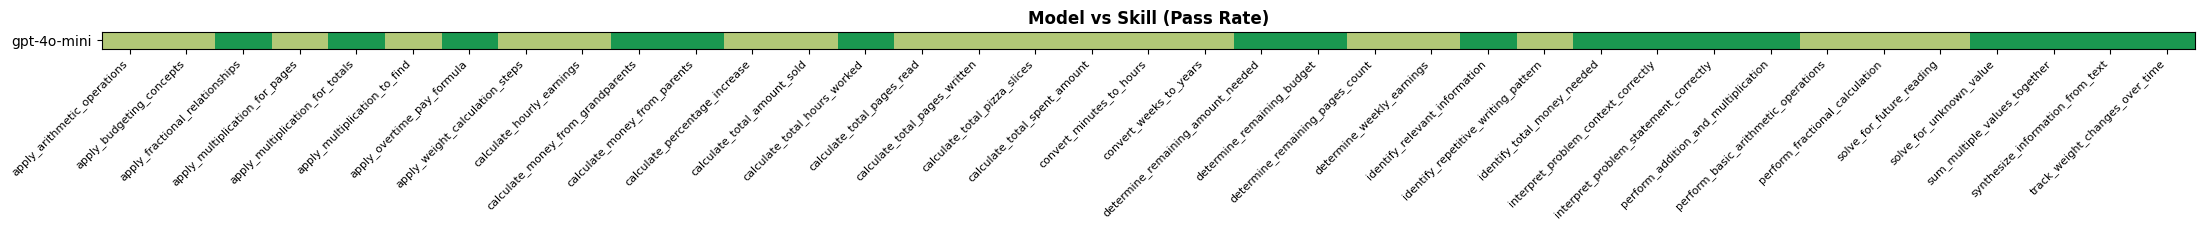

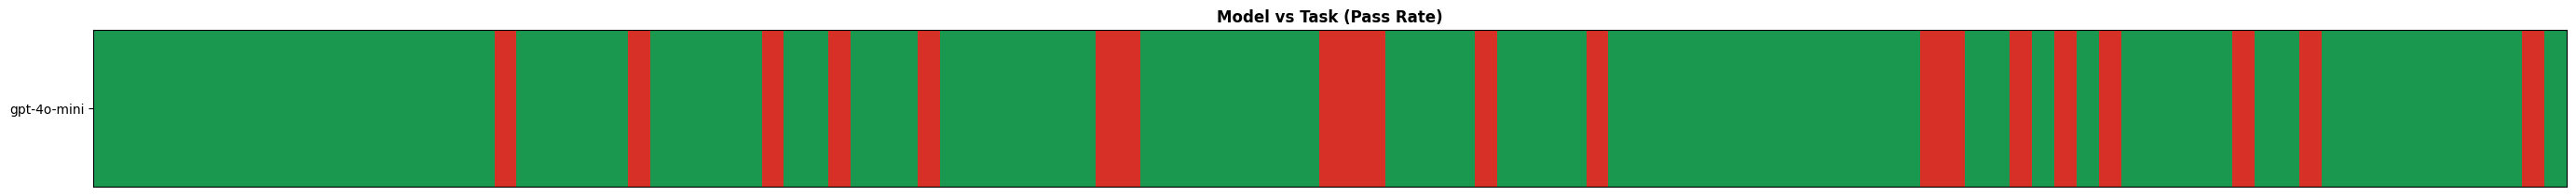

✅ Saved: outputs/model_vs_skill.png
✅ Saved: outputs/model_vs_task.png


In [16]:
# Model vs Skill / Task matrices (single-model setup)
model_name = "gpt-4o-mini"
df_model = df.copy()
df_model["model"] = model_name

# Model vs Skill heatmap (1 x N)
model_skill = df_model.pivot_table(
    index="model",
    columns="skill_name",
    values="is_correct",
    aggfunc="mean"
 )

fig, ax = plt.subplots(figsize=(max(6, len(model_skill.columns) * 0.6), 2.4))
im = ax.imshow(model_skill.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
ax.set_yticks([0])
ax.set_yticklabels(model_skill.index)
ax.set_xticks(range(len(model_skill.columns)))
ax.set_xticklabels(model_skill.columns, rotation=45, ha="right", fontsize=8)
ax.set_title("Model vs Skill (Pass Rate)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/model_vs_skill.png", dpi=150, bbox_inches="tight")
plt.show()

# Model vs Task heatmap (1 x N)
model_task = df_model.pivot_table(
    index="model",
    columns="task_uid",
    values="is_correct",
    aggfunc="mean"
 )

fig, ax = plt.subplots(figsize=(max(6, len(model_task.columns) * 0.25), 2.2))
im = ax.imshow(model_task.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
ax.set_yticks([0])
ax.set_yticklabels(model_task.index)
ax.set_xticks([])
ax.set_title("Model vs Task (Pass Rate)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/model_vs_task.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Saved: outputs/model_vs_skill.png")
print("✅ Saved: outputs/model_vs_task.png")

## Skill vs Task Matrices

Single-model view of skill-to-task performance (and its transpose).
High-density charts, so use them to spot rows/columns with repeated FAIL blocks.
If you need a summary, focus on the worst 3 skills and the top failing tasks.

In [17]:
# Quick summary: worst skills and failing tasks
skill_summary = df.groupby("skill_name").agg(
    total=("is_correct", "count"),
    passed=("is_correct", "sum")
).reset_index()
skill_summary["pass_rate"] = (skill_summary["passed"] / skill_summary["total"]).fillna(0)
skill_summary = skill_summary.sort_values(by="pass_rate", ascending=True)

task_summary = df.groupby("task_uid").agg(
    skill_name=("skill_name", "first"),
    difficulty=("difficulty", "first"),
    total=("is_correct", "count"),
    passed=("is_correct", "sum"),
    problem=("problem", "first")
).reset_index()
task_summary["pass_rate"] = (task_summary["passed"] / task_summary["total"]).fillna(0)
task_summary = task_summary.sort_values(by=["pass_rate", "difficulty"], ascending=[True, False])

print("📉 Worst 3 skills by pass rate")
display(skill_summary[["skill_name", "pass_rate", "passed", "total"]].head(3))
print("\n❌ Top 5 failing tasks")
display(task_summary[["task_uid", "skill_name", "difficulty", "pass_rate", "problem"]].head(5))

📉 Worst 3 skills by pass rate


,skill_name,pass_rate,passed,total
0,apply_arithmetic_operations,0.666667,2,3
1,apply_budgeting_concepts,0.666667,2,3
3,apply_multiplication_for_pages,0.666667,2,3



❌ Top 5 failing tasks


,task_uid,skill_name,difficulty,pass_rate,problem
24,3cea-469b-a61f-3d72,identify_repetitive_writing_pattern,medium,0.0,Tom is making friendship bracelets. He uses a ...
30,4bae-3926-9706-a417,solve_for_future_reading,medium,0.0,Liam has a reading goal of finishing 120 pages...
37,5b64-0443-7f9f-5d0d,convert_weeks_to_years,medium,0.0,Sarah saved for 90 weeks to buy a new bike. Ho...
45,6e33-7140-4259-08d0,perform_fractional_calculation,medium,0.0,Liam has 3/4 of a chocolate bar. He gives 1/2 ...
82,c516-8113-481f-1999,calculate_total_pages_written,medium,0.0,Tom is writing a book. He wrote 20 pages in th...


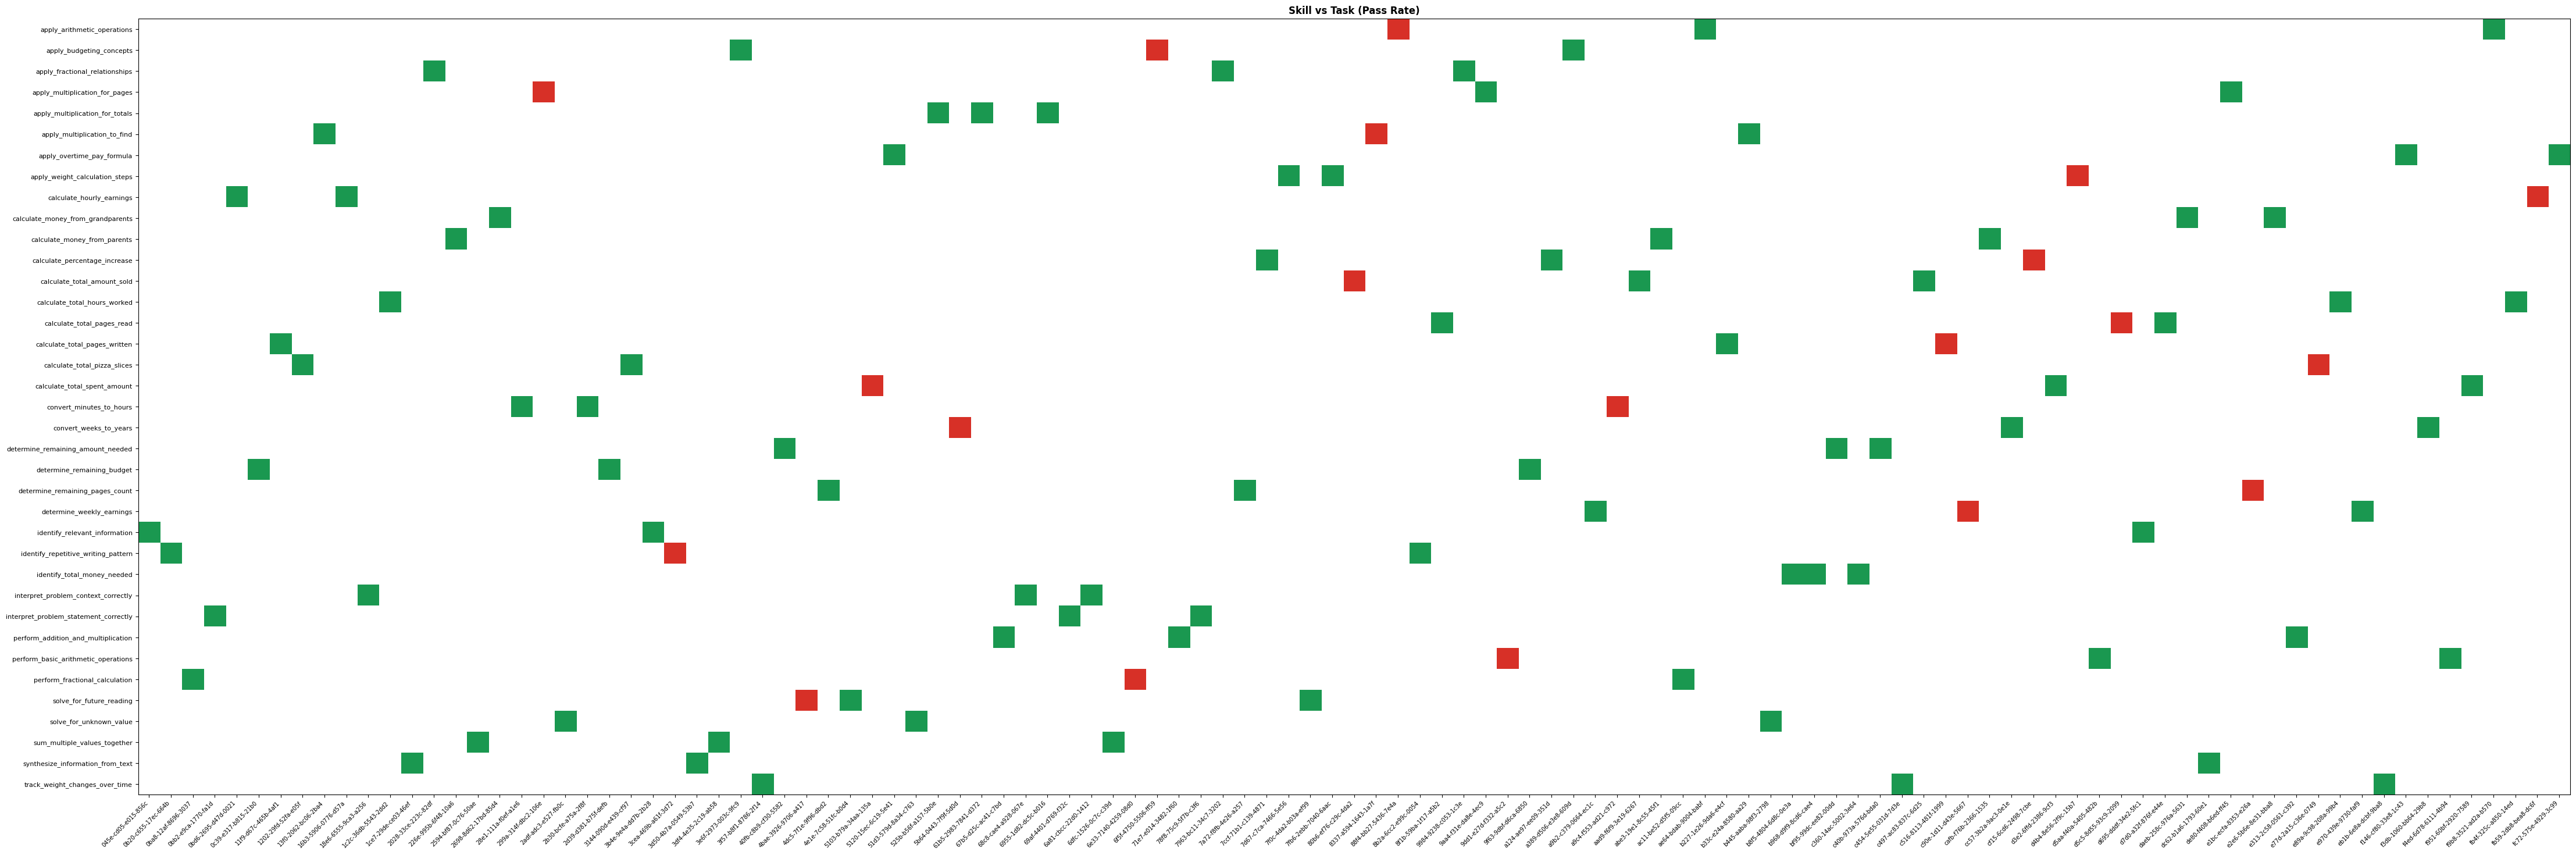

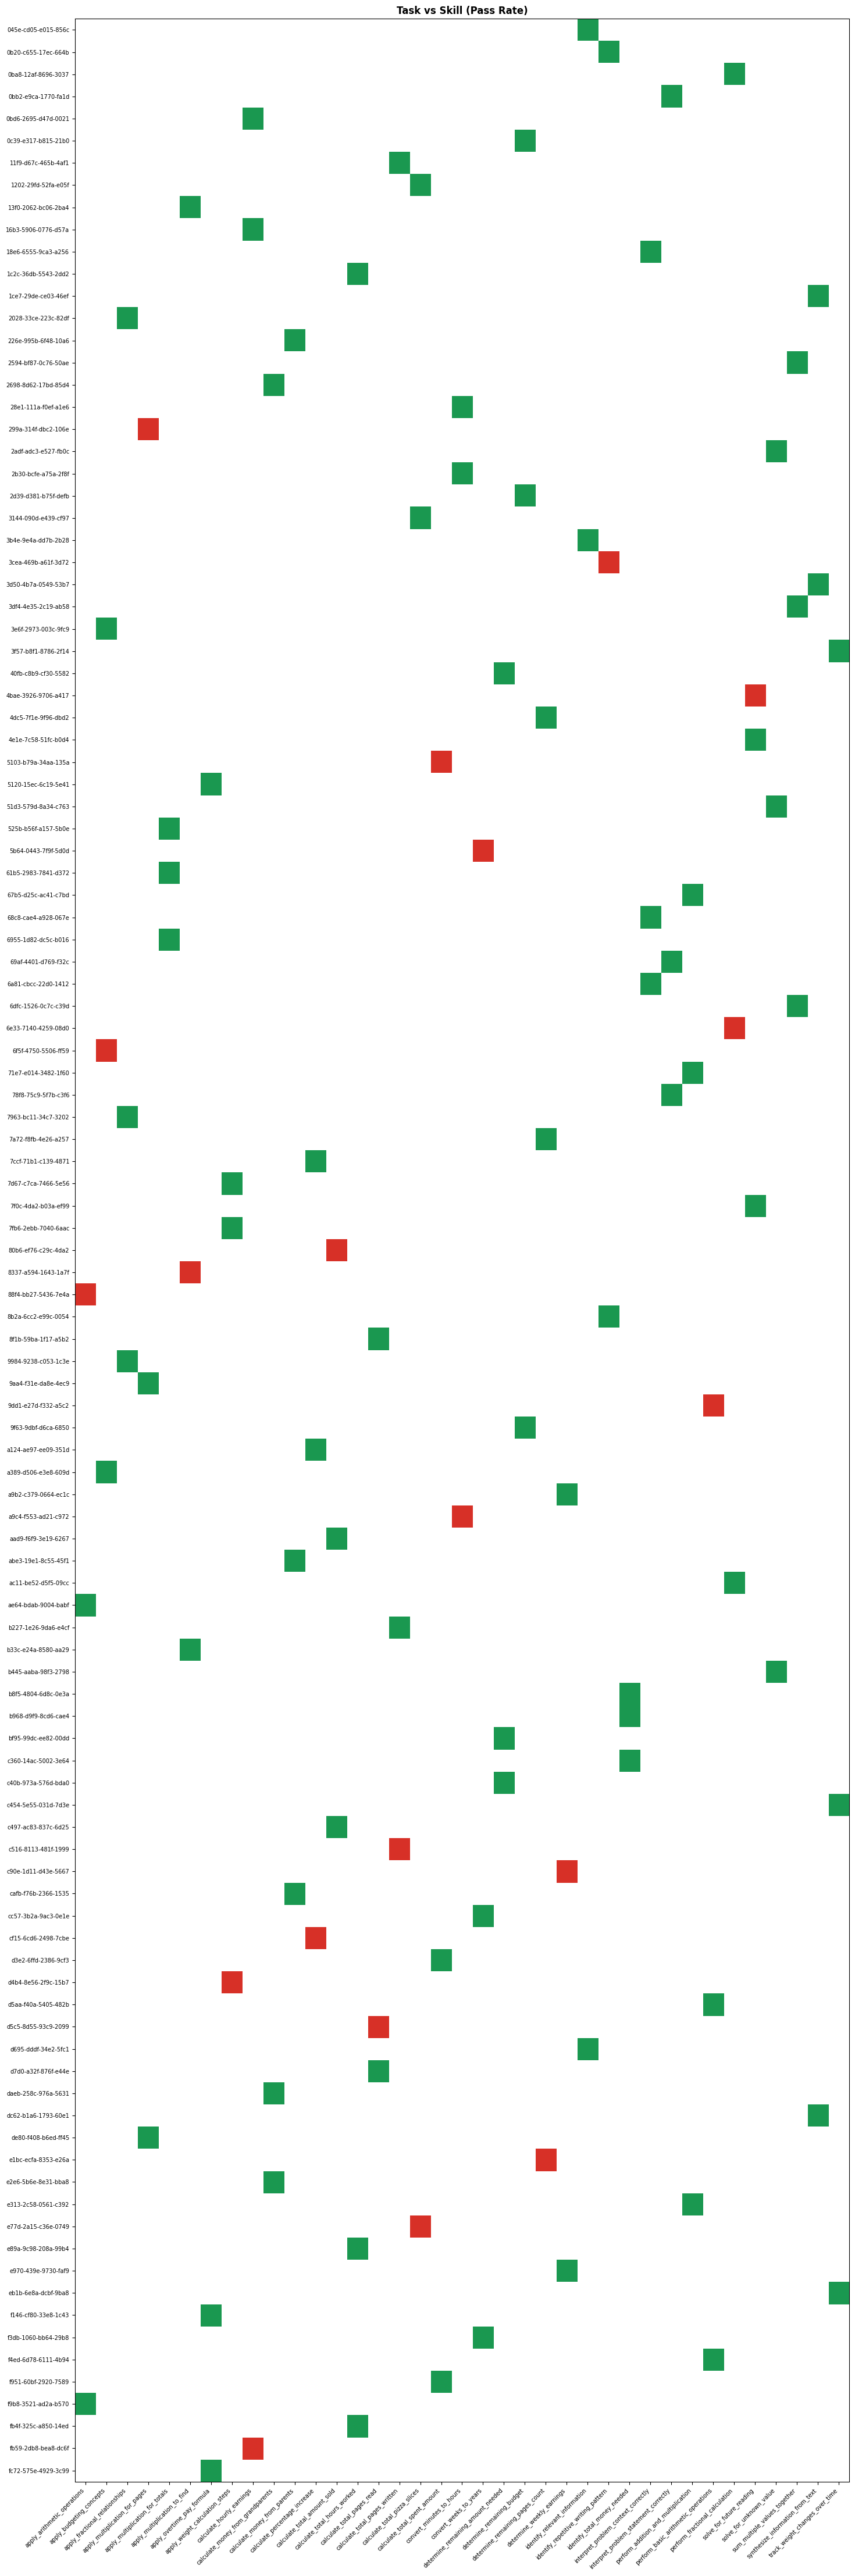

✅ Saved: outputs/skill_vs_task.png
✅ Saved: outputs/task_vs_skill.png


In [18]:
# Skill vs Task heatmap
skill_task = df.pivot_table(
    index="skill_name",
    columns="task_uid",
    values="is_correct",
    aggfunc="mean"
 )

fig, ax = plt.subplots(figsize=(max(10, len(skill_task.columns) * 0.4), max(5, len(skill_task.index) * 0.4)))
im = ax.imshow(skill_task.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
ax.set_yticks(range(len(skill_task.index)))
ax.set_yticklabels(skill_task.index, fontsize=8)
ax.set_xticks(range(len(skill_task.columns)))
ax.set_xticklabels(skill_task.columns, rotation=45, ha="right", fontsize=7)
ax.set_title("Skill vs Task (Pass Rate)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/skill_vs_task.png", dpi=150, bbox_inches="tight")
plt.show()

# Task vs Skill heatmap (transpose)
task_skill = skill_task.T
fig, ax = plt.subplots(figsize=(max(10, len(task_skill.columns) * 0.4), max(5, len(task_skill.index) * 0.4)))
im = ax.imshow(task_skill.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
ax.set_yticks(range(len(task_skill.index)))
ax.set_yticklabels(task_skill.index, fontsize=7)
ax.set_xticks(range(len(task_skill.columns)))
ax.set_xticklabels(task_skill.columns, rotation=45, ha="right", fontsize=7)
ax.set_title("Task vs Skill (Pass Rate)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/task_vs_skill.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Saved: outputs/skill_vs_task.png")
print("✅ Saved: outputs/task_vs_skill.png")